In [1]:
import sys; sys.path.insert(0, '.')
from mise_utils import viz, foundations
from mise_utils.viz import COLORS
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
viz.apply_mise_style()

# Preludio — Los Cimientos Científicos

*Un recorrido por las raíces matemáticas y físicas de la ciencia de sistemas complejos.*

## 1. El problema de tres cuerpos

A finales del siglo XIX, el rey Oscar II de Suecia ofreció un premio a quien pudiera demostrar la estabilidad del sistema solar. Henri Poincaré, al intentar resolver el problema de tres cuerpos interactuando gravitacionalmente, descubrió algo perturbador: las ecuaciones eran deterministas, pero las trayectorias eran impredecibles a largo plazo. Pequeños errores en las condiciones iniciales crecían sin límite. Había descubierto el caos determinista.

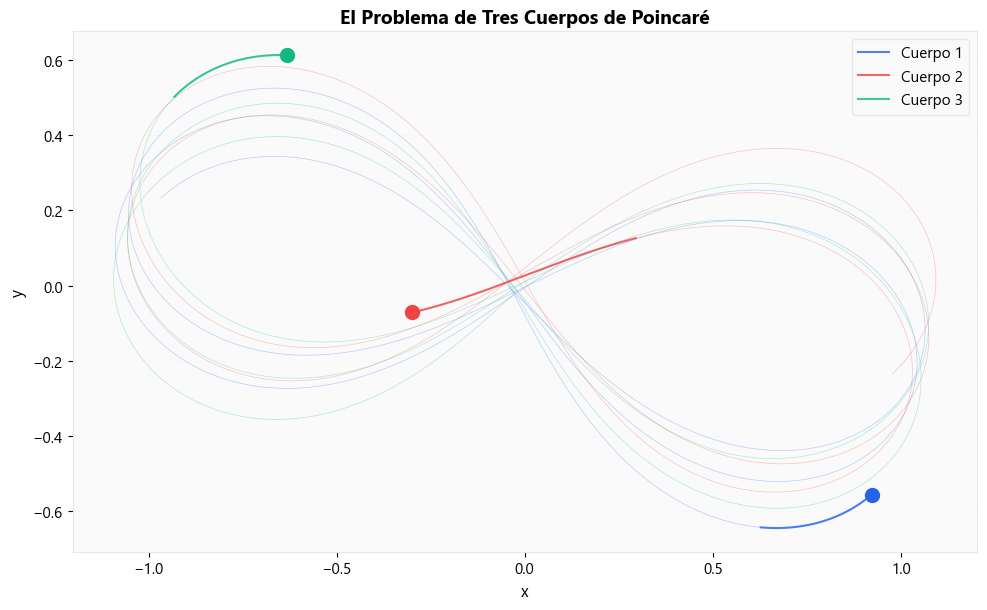

In [2]:
# Simulación del problema de tres cuerpos
resultado = foundations.tres_cuerpos(T=15)
foundations.plot_tres_cuerpos(resultado, titulo='El Problema de Tres Cuerpos de Poincaré')
plt.show()

(<Figure size 1500x1000 with 6 Axes>,
 array([<Axes: title={'center': 't = 0.0'}>,
        <Axes: title={'center': 't = 3.0'}>,
        <Axes: title={'center': 't = 6.0'}>,
        <Axes: title={'center': 't = 9.0'}>,
        <Axes: title={'center': 't = 12.0'}>,
        <Axes: title={'center': 't = 15.0'}>], dtype=object))

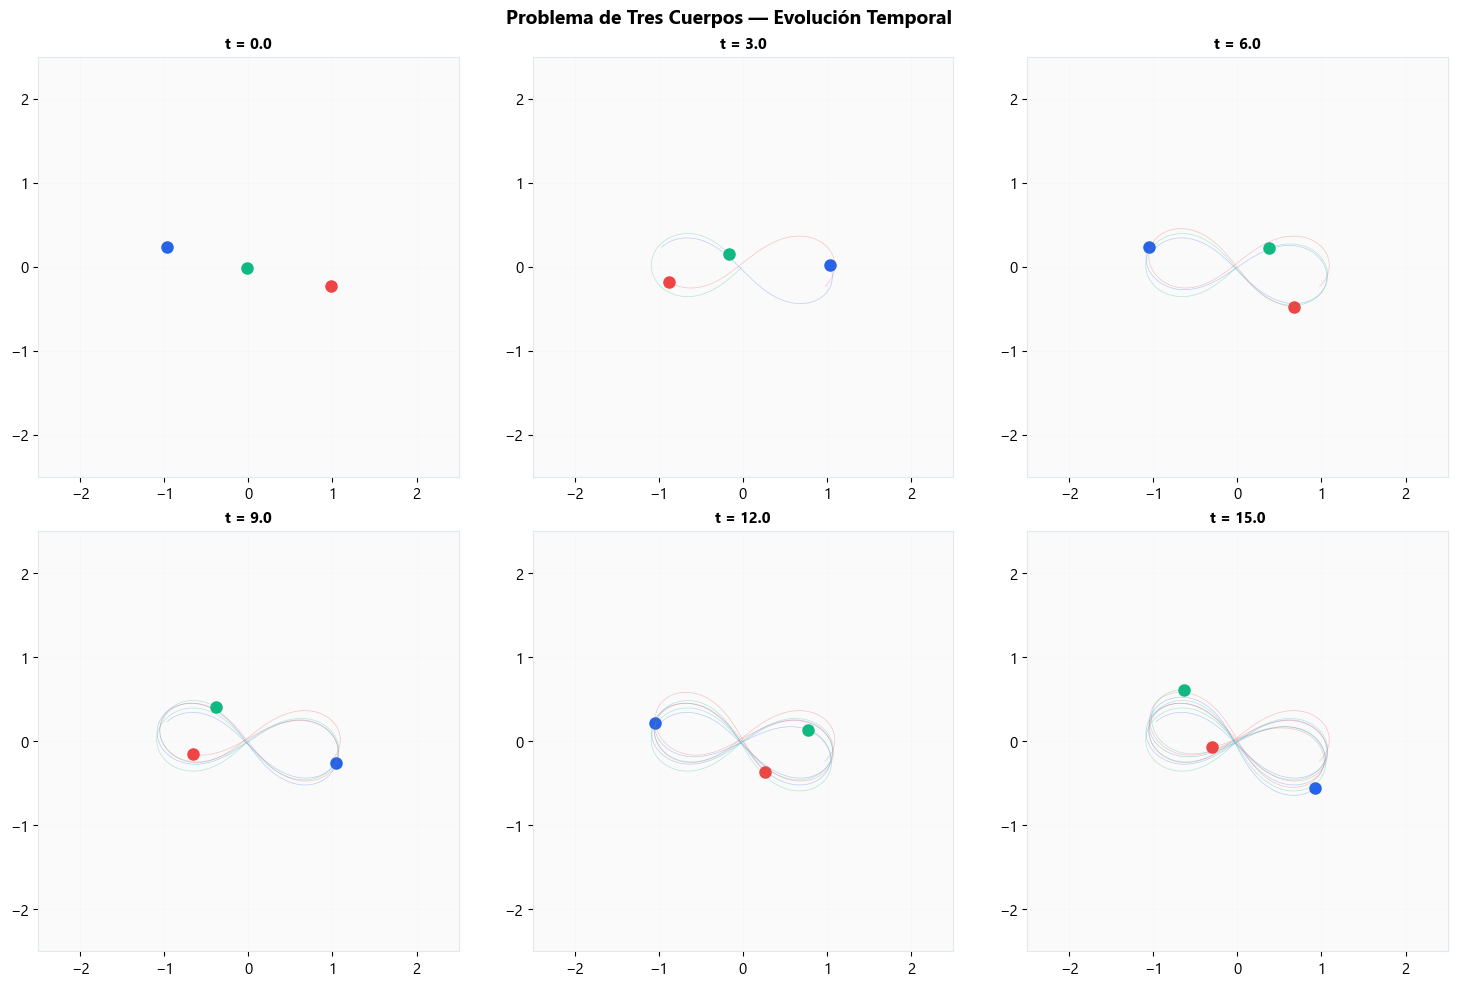

In [3]:
foundations.plot_tres_cuerpos_frames(resultado)

**Insight:** "Tres cuerpos, ecuaciones conocidas, trayectorias impredecibles. Poincaré descubrió que el determinismo no garantiza la predictibilidad."

## 2. La ecuación logística

Imagina una población de conejos en una isla. La tasa de crecimiento está dada por un parámetro $r$. Al principio, la población crece exponencialmente, pero a medida que los recursos se agotan (representado por el término $1-x$), el crecimiento se frena. Esta simple ecuación captura la interacción no lineal entre crecimiento y limitación de recursos.

(<Figure size 1400x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Equilibrio estable (r=2.8)'}, xlabel='Iteración n', ylabel='$x_n$'>,
         <Axes: title={'center': 'Ciclo de período 2 (r=3.3)'}, xlabel='Iteración n', ylabel='$x_n$'>],
        [<Axes: title={'center': 'Ciclo de período 4 (r=3.5)'}, xlabel='Iteración n', ylabel='$x_n$'>,
         <Axes: title={'center': 'Caos (r=3.9)'}, xlabel='Iteración n', ylabel='$x_n$'>]],
       dtype=object))

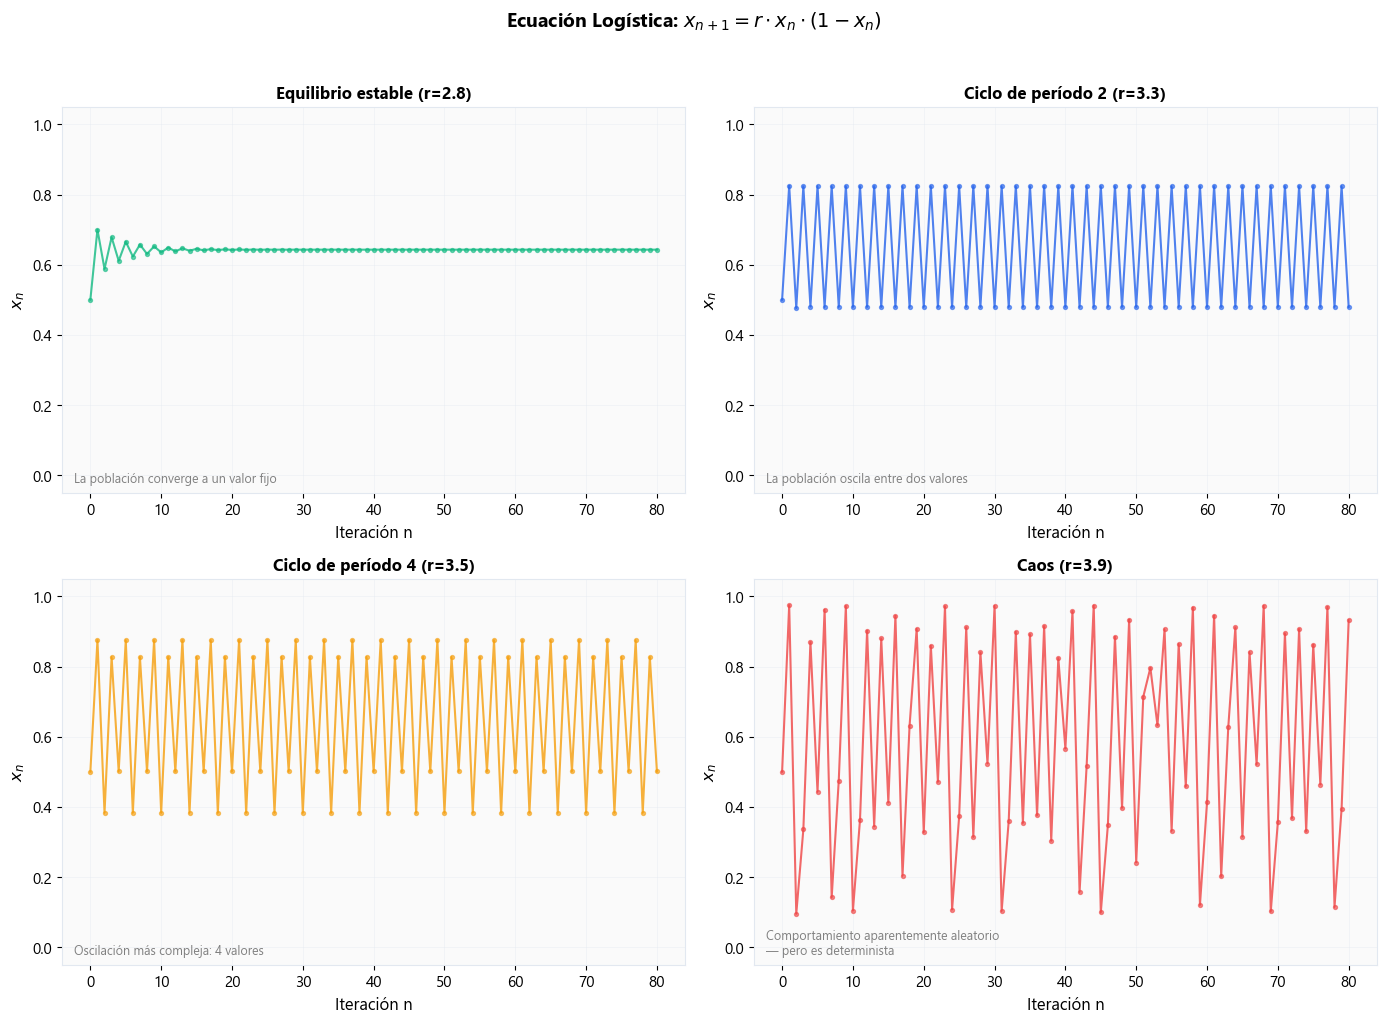

In [4]:
foundations.plot_logistica_regimenes()

Los paneles muestran cómo al aumentar la tasa de crecimiento ($r$), la población pasa de estabilizarse en un número fijo, a oscilar entre dos valores, a oscilar entre cuatro, y finalmente a comportarse de forma aparentemente aleatoria o caótica.

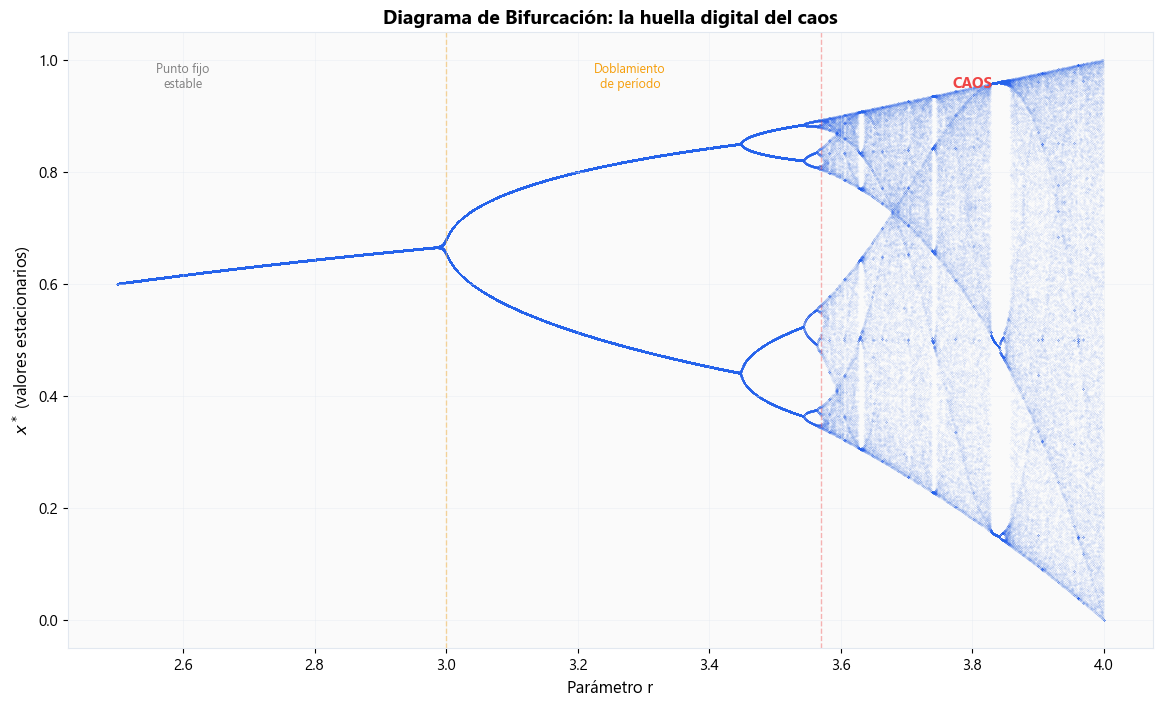

In [5]:
bif = foundations.diagrama_bifurcacion(r_min=2.5, r_max=4.0, n_r=3000)
foundations.plot_bifurcacion(bif, titulo='Diagrama de Bifurcación: la huella digital del caos')
plt.show()

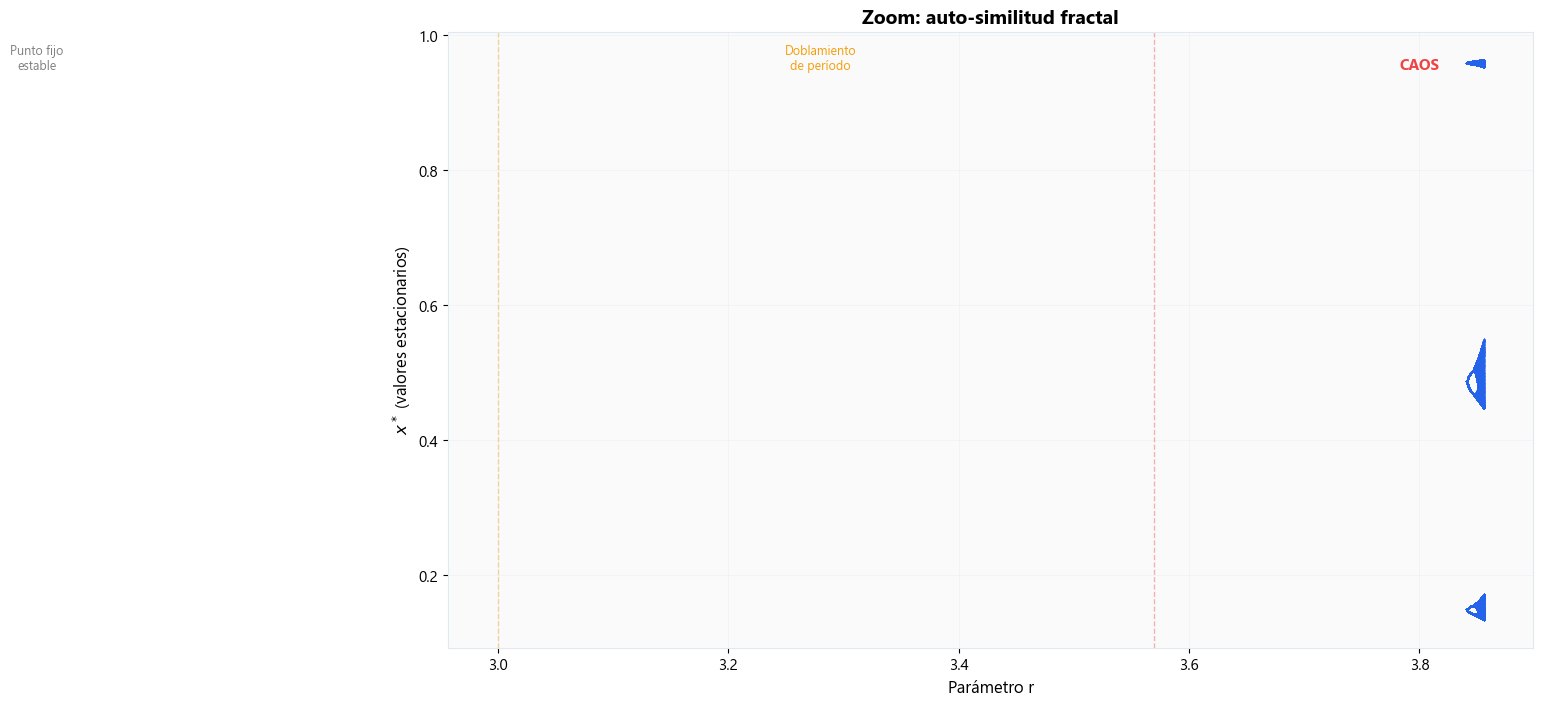

In [6]:
# Zoom: estructura fractal — el patrón se repite a toda escala
bif_zoom = foundations.diagrama_bifurcacion(r_min=3.84, r_max=3.856, n_r=3000)
foundations.plot_bifurcacion(bif_zoom, titulo='Zoom: auto-similitud fractal')
plt.show()

**Insight:** "Una ecuación, un parámetro, toda la riqueza del universo. El caos no es desorden — tiene estructura."

## 3. El atractor de Lorenz

En 1963, el meteorólogo Edward Lorenz simulaba el clima en su computadora. Para ahorrar tiempo, reingresó datos de una corrida anterior, pero redondeados (0.506 en lugar de 0.506127). El resultado fue un clima completamente diferente. Había descubierto el "efecto mariposa" (butterfly effect): sensibilidad extrema a las condiciones iniciales.

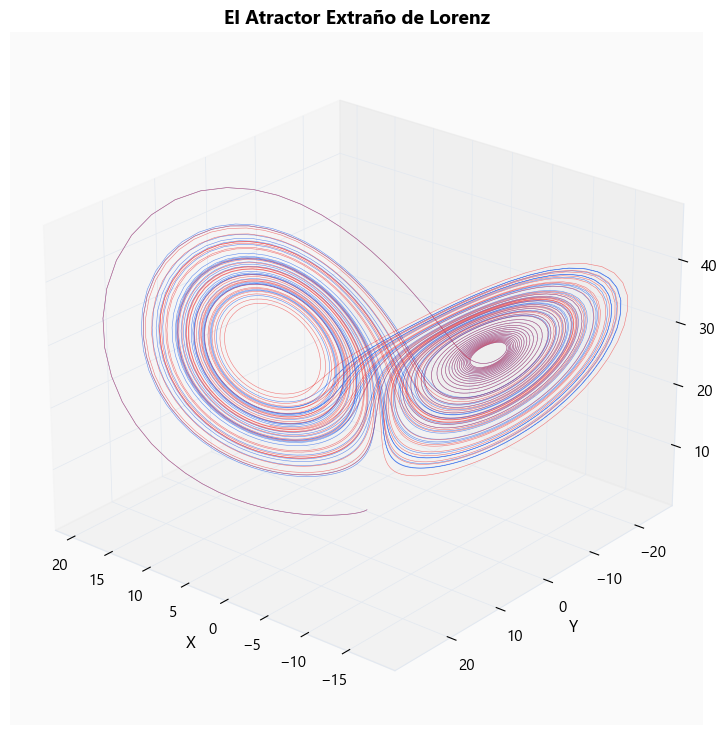

In [7]:
resultado = foundations.lorenz_attractor(T=50, y0=[1,1,1], y0_perturbado=[1.001,1,1])
foundations.plot_lorenz_3d(resultado, titulo='El Atractor Extraño de Lorenz')
plt.show()

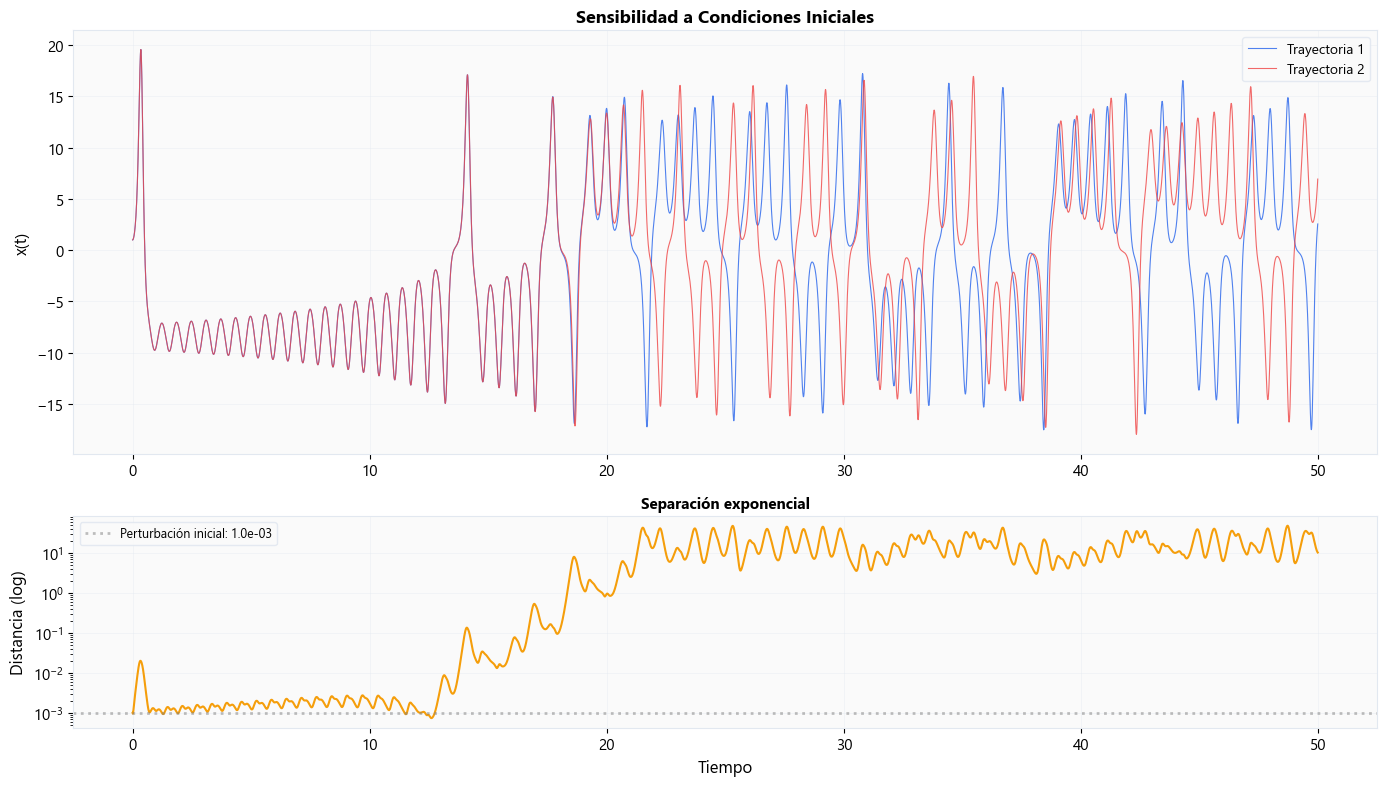

In [8]:
foundations.plot_lorenz_divergencia(resultado, titulo='Sensibilidad a Condiciones Iniciales')
plt.show()

**Insight:** "Determinista pero impredecible. Las dos trayectorias empiezan casi idénticas pero divergen exponencialmente. Esto limita fundamentalmente nuestra capacidad de predecir."

## 4. Péndulo simple vs péndulo doble

Según el Teorema de Poincaré-Bendixson, el caos no puede existir en sistemas continuos de 2 dimensiones (como un péndulo simple). Las trayectorias no pueden cruzarse sin intersecarse de formas que el plano restringe. Sin embargo, en 4 dimensiones (como un péndulo doble), hay suficiente "espacio" para que emerja el caos.

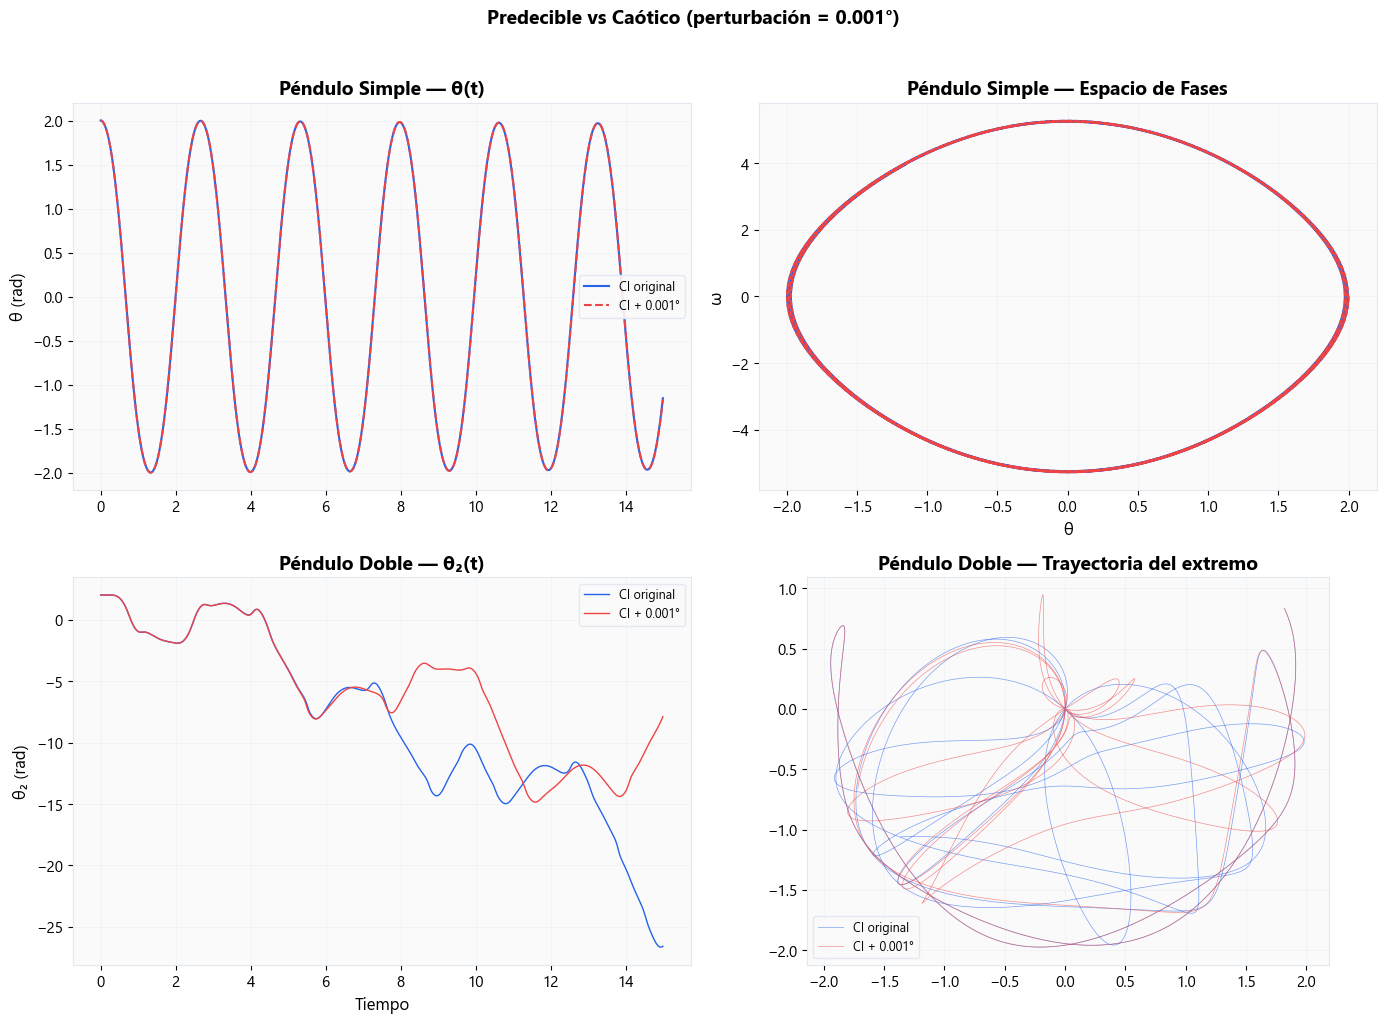

In [9]:
foundations.plot_pendulos_comparacion(perturbacion=0.001, T=15)
plt.show()

**Insight:** "El péndulo simple es predecible; el doble es caótico. La diferencia: dimensionalidad. El caos necesita al menos 3 variables continuas."

## 5. Sincronización espontánea (Kuramoto)

En 1665, Christiaan Huygens observó que dos relojes de péndulo en la misma pared terminaban sincronizándose. Este modelo, estudiado formalmente por Yoshiki Kuramoto, muestra cómo osciladores con frecuencias naturales distintas pueden sincronizarse espontáneamente si están acoplados mediante una plataforma común.

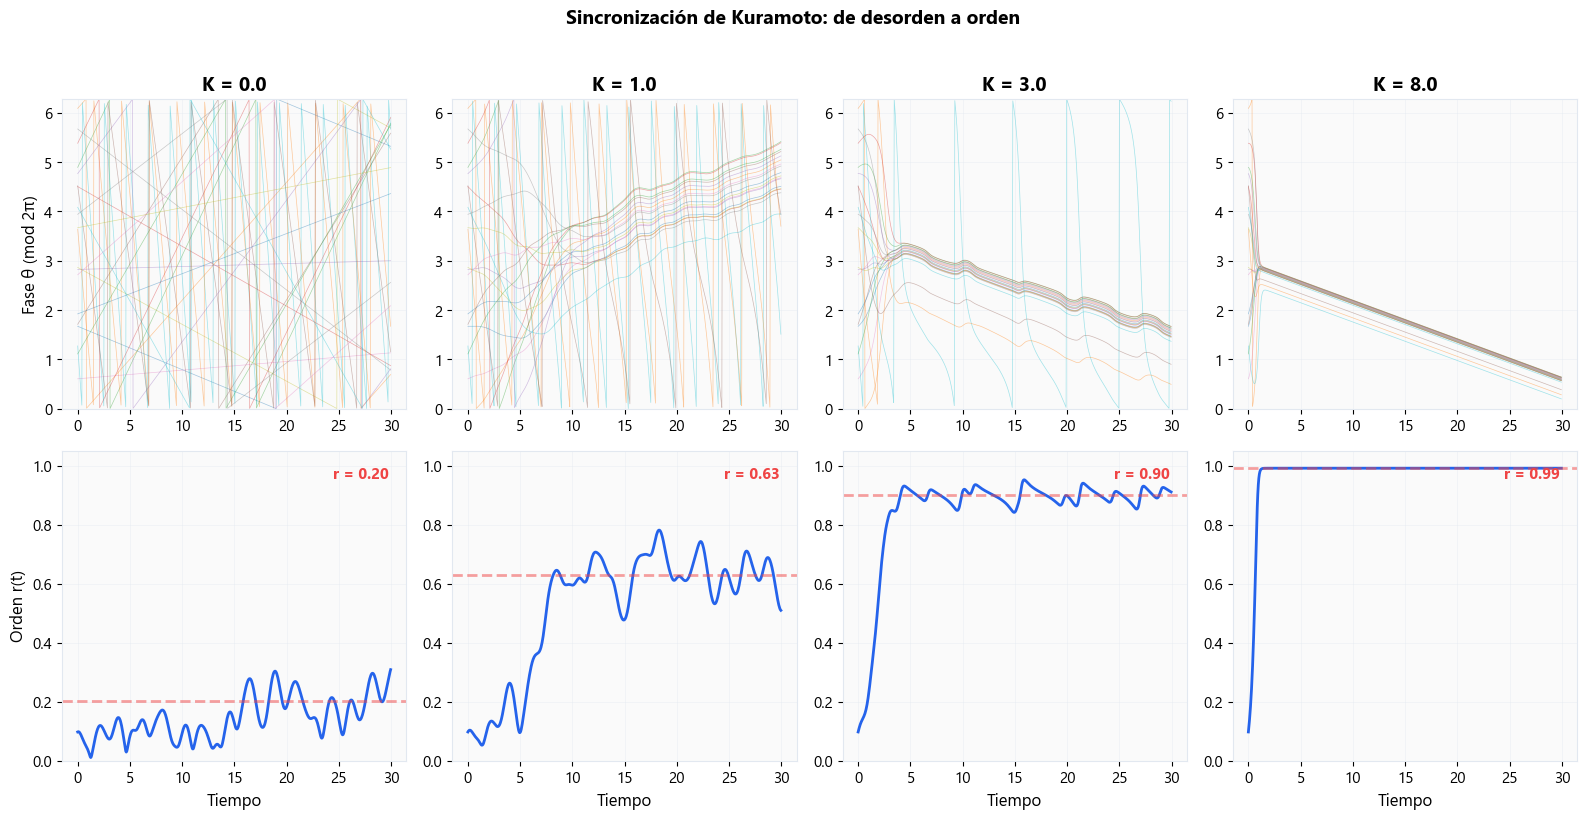

In [10]:
foundations.plot_kuramoto_transicion(K_values=[0.0, 1.0, 3.0, 8.0], N=50)
plt.show()

**Insight:** "La auto-organización no requiere director de orquesta — emerge de la interacción. Los generadores eléctricos deben sincronizarse a 60 Hz: el mismo fenómeno."

## 6. Transición de fase en redes

Cuando conectamos nodos aleatoriamente en una red, la conectividad global no crece de forma suave. Existe un punto crítico donde de repente emerge un "componente gigante", de manera similar a cómo el agua se congela (percolation). La transición es abrupta.

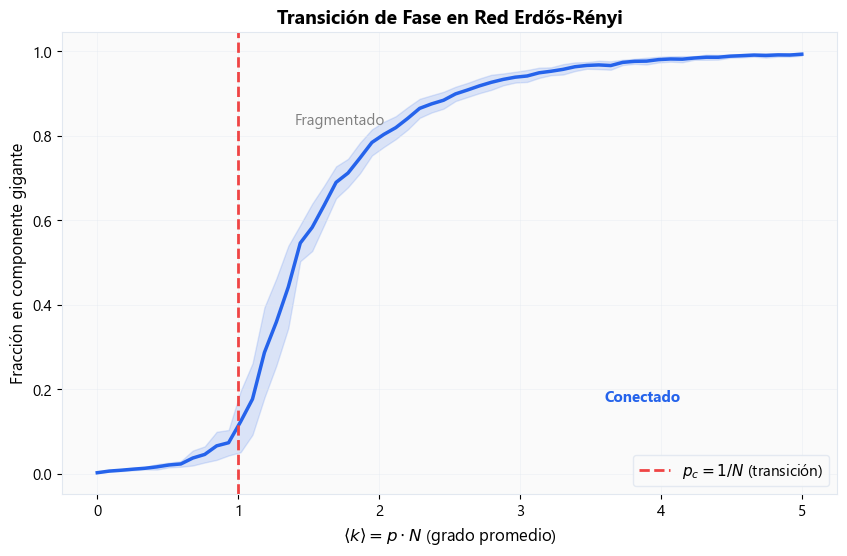

In [11]:
resultado = foundations.percolacion_red(n=500, n_muestras=30)
foundations.plot_percolacion(resultado)
plt.show()

**Insight:** "La red no se fragmenta gradualmente — colapsa en un punto crítico. ¿Cuántas líneas de transmisión deben fallar antes de que el SIN colapse?"

## 7. Criticidad auto-organizada (pila de arena)

El modelo propuesto por Bak, Tang y Wiesenfeld (1987) ilustra cómo algunos sistemas complejos evolucionan naturalmente hacia un estado crítico sin intervención externa. Al agregar granos de arena uno por uno, la pila desarrolla avalanchas de todos los tamaños (self-organized criticality).

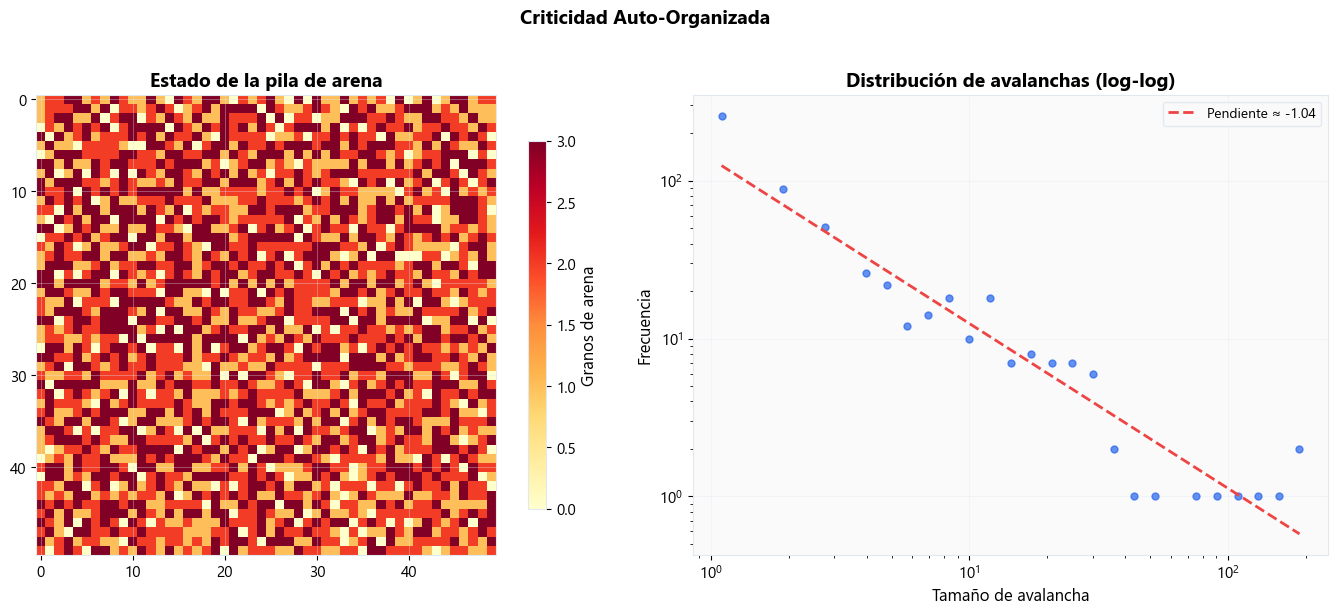

In [12]:
resultado = foundations.sandpile_btw(grid_size=50, n_grains=5000)
foundations.plot_sandpile(resultado, titulo='Criticidad Auto-Organizada')
plt.show()

**Insight:** "El sistema se auto-organiza hacia la criticidad. Las avalanchas siguen una ley de potencia — los eventos extremos son inevitables, no accidentes."

## 8. La tabla de Strogatz

Steven Strogatz propuso una clasificación de los sistemas dinámicos según su linealidad y dimensionalidad. Es como una tabla periódica del comportamiento matemático.

In [13]:
tabla = foundations.tabla_strogatz_visual()
tabla.style.set_properties(**{'text-align': 'left'})

,"λ₁, λ₂",Tipo,Comportamiento,Ejemplo
0,"Reales, ambos < 0",Nodo estable,Convergencia monotónica,Amortiguamiento sobredamped
1,"Reales, ambos > 0",Nodo inestable,Divergencia monotónica,Explosión exponencial
2,"Reales, signos opuestos",Punto silla,Atrae y repele,Equilibrio de mercado inestable
3,"Complejos, Re < 0",Espiral estable,Oscilaciones amortiguadas,Precio que oscila y converge
4,"Complejos, Re > 0",Espiral inestable,Oscilaciones crecientes,Ciclo inversión sin control
5,Imaginarios puros,Centro,Oscilaciones perpetuas,Péndulo sin fricción


**Insight:** "Los eigenvalores del Jacobiano son como un diagnóstico médico del punto de equilibrio — nos dicen si es estable, oscilatorio o caótico, sin necesidad de simular."

## 9. El mapa del campo

La ciencia de los sistemas complejos bebe de muchas disciplinas:

*   **Sistemas Dinámicos y Teoría del Caos**: El estudio matemático del cambio temporal (Edward Lorenz, Henri Poincaré).
*   **Física Estadística**: Transiciones de fase, criticidad, leyes de potencia (Per Bak).
*   **Teoría de Redes**: Topología e interacciones (Steven Strogatz, Albert-László Barabási).
*   **Sistemas Adaptativos Complejos**: Evolución, aprendizaje, emergencia.

**Instituciones Clave:**
*   Santa Fe Institute (SFI): Pioneros mundiales en ciencias de la complejidad.
*   New England Complex Systems Institute (NECSI).
*   Max Planck Institute for Dynamics and Self-Organization.
*   London Mathematical Laboratory (LML).

**Lecturas Recomendadas:**
*   *Sync* por Steven Strogatz: La ciencia de la sincronización espontánea.
*   *Complexity: A Guided Tour* por Melanie Mitchell: Excelente introducción general.
*   *Nonlinear Dynamics and Chaos* por Steven Strogatz: El libro de texto estándar.

> *"El mercado eléctrico ES un sistema dinámico no-lineal acoplado en red. Los generadores son osciladores acoplados, los precios son funciones no-lineales, las decisiones de inversión tienen retardos, las fallas se propagan como cascadas. La ciencia de la complejidad no es una analogía — es la descripción matemática exacta de lo que ocurre. El curso toma las herramientas más accesibles de esta tradición y las aplica al sector. Pero ahora saben que hay un edificio científico enorme detrás."*